<a href="https://colab.research.google.com/github/UB2002/AI-Text_Summarizer/blob/main/cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import math
from xml.etree import ElementTree as ET
from pathlib import Path

In [106]:


# 1. Select CNN Backbone: ResNet50
class ResNetBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super(ResNetBackbone, self).__init__()
        base_model = torchvision.models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)
        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool
        self.layer1 = base_model.layer1
        self.layer2 = base_model.layer2
        self.layer3 = base_model.layer3
        self.layer4 = base_model.layer4
        if pretrained:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        feat1 = self.layer3(x)
        feat2 = self.layer4(feat1)
        return feat1, feat2

In [107]:
class ExtraLayers(nn.Module):
    def __init__(self):
        super(ExtraLayers, self).__init__()
        self.extra1 = nn.Sequential(
            nn.Conv2d(2048, 256, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        self.extra2 = nn.Sequential(
            nn.Conv2d(512, 128, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        self.extra3 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        feat3 = self.extra1(x)
        feat4 = self.extra2(feat3)
        feat5 = self.extra3(feat4)
        return feat3, feat4, feat5

# SSD Model
class SSDModel(nn.Module):
    def __init__(self, num_classes):
        super(SSDModel, self).__init__()
        self.backbone     = ResNetBackbone()
        self.extra_layers = ExtraLayers()
        self.num_classes  = num_classes

        # 1) Mirror your generate_default_boxes logic to get [4,4,4,4,3]
        feature_maps  = [19, 10, 5, 3, 1]
        aspect_ratios = [1, 2, 0.5, 1]
        anchors_per_map = []
        for k, _ in enumerate(feature_maps):
            count = 0
            for ar_idx in range(len(aspect_ratios)):
                # only include the special "s_prime" anchor if not on the last map
                if ar_idx == 3 and k == len(feature_maps)-1:
                    continue
                count += 1
            anchors_per_map.append(count)
        # anchors_per_map == [4,4,4,4,3]

        # 2) Build heads using per-map anchor counts
        self.loc_heads  = nn.ModuleList()
        self.conf_heads = nn.ModuleList()
        in_channels = [1024, 2048, 512, 256, 256]

        for ch, num_anchors in zip(in_channels, anchors_per_map):
            self.loc_heads.append(
                nn.Conv2d(ch, num_anchors * 4, kernel_size=3, padding=1)
            )
            self.conf_heads.append(
                nn.Conv2d(ch, num_anchors * num_classes, kernel_size=3, padding=1)
            )

    def forward(self, x):
        feat1, feat2           = self.backbone(x)
        feat3, feat4, feat5    = self.extra_layers(feat2)
        features = [feat1, feat2, feat3, feat4, feat5]

        loc_preds, conf_preds = [], []
        for feat, loc_head, conf_head in zip(
                features, self.loc_heads, self.conf_heads):
            # permute + flatten exactly as before
            lp = loc_head(feat).permute(0,2,3,1).contiguous()
            lp = lp.view(lp.size(0), -1, 4)
            cp = conf_head(feat).permute(0,2,3,1).contiguous()
            cp = cp.view(cp.size(0), -1, self.num_classes)

            loc_preds.append(lp)
            conf_preds.append(cp)

        loc_preds  = torch.cat(loc_preds,  dim=1)  # [B, 1983, 4]
        conf_preds = torch.cat(conf_preds, dim=1)  # [B, 1983, num_classes]
        return loc_preds, conf_preds

In [108]:
# def generate_default_boxes():
#     feature_maps = [19, 10, 5, 3, 1]
#     scales = [0.2, 0.375, 0.55, 0.725, 0.9]
#     aspect_ratios = [1, 2, 0.5, 1]
#     default_boxes = []
#     for k, fm_size in enumerate(feature_maps):
#         for i in range(fm_size):
#             for j in range(fm_size):
#                 cx = (j + 0.5) / fm_size
#                 cy = (i + 0.5) / fm_size
#                 s = scales[k]
#                 for idx, ar in enumerate(aspect_ratios):
#                     if idx == 3:
#                         s_prime = math.sqrt(s * (scales[k + 1] if k + 1 < len(scales) else 0.95))
#                         w = s_prime
#                         h = s_prime
#                     else:
#                         w = s * math.sqrt(ar)
#                         h = s / math.sqrt(ar)
#                     default_boxes.append([cx, cy, w, h])
#     return torch.tensor(default_boxes, dtype=torch.float32)


import math
import torch

def generate_default_boxes():
    feature_maps  = [19, 10, 5, 3, 1]
    scales        = [0.2, 0.375, 0.55, 0.725, 0.9]
    aspect_ratios = [1, 2, 0.5, 1]
    default_boxes = []

    for k, fm_size in enumerate(feature_maps):
        for i in range(fm_size):
            for j in range(fm_size):
                cx = (j + 0.5) / fm_size
                cy = (i + 0.5) / fm_size
                s  = scales[k]

                for idx, ar in enumerate(aspect_ratios):
                    # ---- FIX: only compute the "next-scale" box if k+1 < len(scales)
                    if idx == 3 and (k + 1) < len(scales):
                        s_prime = math.sqrt(s * scales[k + 1])
                        w = s_prime
                        h = s_prime
                    elif idx == 3:
                        # skip this anchor on the last layer
                        continue
                    else:
                        w = s * math.sqrt(ar)
                        h = s / math.sqrt(ar)

                    default_boxes.append([cx, cy, w, h])

    return torch.tensor(default_boxes, dtype=torch.float32)


In [109]:
def compute_iou(default_boxes, gt_boxes):
    d_xmin = default_boxes[:, 0] - default_boxes[:, 2] / 2
    d_ymin = default_boxes[:, 1] - default_boxes[:, 3] / 2
    d_xmax = default_boxes[:, 0] + default_boxes[:, 2] / 2
    d_ymax = default_boxes[:, 1] + default_boxes[:, 3] / 2

    inter_xmin = torch.max(d_xmin[:, None], gt_boxes[:, 0])
    inter_ymin = torch.max(d_ymin[:, None], gt_boxes[:, 1])
    inter_xmax = torch.min(d_xmax[:, None], gt_boxes[:, 2])
    inter_ymax = torch.min(d_ymax[:, None], gt_boxes[:, 3])

    inter_w = (inter_xmax - inter_xmin).clamp(min=0)
    inter_h = (inter_ymax - inter_ymin).clamp(min=0)
    inter_area = inter_w * inter_h

    d_area = (d_xmax - d_xmin) * (d_ymax - d_ymin)
    gt_area = (gt_boxes[:, 2] - gt_boxes[:, 0]) * (gt_boxes[:, 3] - gt_boxes[:, 1])
    union_area = d_area[:, None] + gt_area - inter_area

    return inter_area / union_area

In [110]:
def match_default_boxes(gt_boxes, gt_labels, default_boxes, threshold=0.5):
    iou = compute_iou(default_boxes, gt_boxes)
    max_iou_per_default, max_gt_per_default = iou.max(dim=1)
    max_iou_per_gt, max_default_per_gt = iou.max(dim=0)

    pos_mask = max_iou_per_default > threshold
    conf_targets = torch.zeros_like(max_gt_per_default)
    loc_targets = torch.zeros_like(default_boxes)

    for i in range(len(gt_boxes)):
        default_idx = max_default_per_gt[i]
        pos_mask[default_idx] = True
        conf_targets[default_idx] = gt_labels[i]

    conf_targets[pos_mask] = gt_labels[max_gt_per_default[pos_mask]]

    gt_cx = (gt_boxes[:, 0] + gt_boxes[:, 2]) / 2
    gt_cy = (gt_boxes[:, 1] + gt_boxes[:, 3]) / 2
    gt_w = gt_boxes[:, 2] - gt_boxes[:, 0]
    gt_h = gt_boxes[:, 3] - gt_boxes[:, 1]

    loc_targets[pos_mask, 0] = (gt_cx[max_gt_per_default[pos_mask]] - default_boxes[pos_mask, 0]) / default_boxes[pos_mask, 2]
    loc_targets[pos_mask, 1] = (gt_cy[max_gt_per_default[pos_mask]] - default_boxes[pos_mask, 1]) / default_boxes[pos_mask, 3]
    loc_targets[pos_mask, 2] = torch.log(gt_w[max_gt_per_default[pos_mask]] / default_boxes[pos_mask, 2])
    loc_targets[pos_mask, 3] = torch.log(gt_h[max_gt_per_default[pos_mask]] / default_boxes[pos_mask, 3])

    return pos_mask, loc_targets, conf_targets

In [111]:
class SSDLoss(nn.Module):
    def __init__(self, neg_pos_ratio=3):
        super().__init__()
        self.smooth_l1     = nn.SmoothL1Loss(reduction="sum")
        self.neg_pos_ratio = neg_pos_ratio

    def forward(self, loc_preds, conf_preds, loc_targets, conf_targets, pos_mask):
        B, N, C4 = loc_preds.shape  # N will be 1983
        _, _, C = conf_preds.shape

        # flatten [B*N, …]
        loc_p = loc_preds.view(B*N, 4)
        loc_t = loc_targets.view(B*N, 4)
        conf_p= conf_preds.view(B*N, C)
        conf_t= conf_targets.view(B*N)
        pos_m = pos_mask.view(B*N)

        # loc loss on positives only
        pos_idx = pos_m.nonzero(as_tuple=False).squeeze(1)
        loc_loss = self.smooth_l1(loc_p[pos_idx], loc_t[pos_idx])

        # confidence loss with hard‐neg mining
        log_prob = torch.log_softmax(conf_p, dim=1)
        ce_per = -log_prob[torch.arange(B*N), conf_t]

        num_pos = pos_m.sum()
        num_neg = torch.clamp(self.neg_pos_ratio * num_pos, max=(B*N-num_pos))

        # suppress positives, sort negatives
        neg_losses = ce_per.clone()
        neg_losses[pos_m] = -1e6
        neg_idx = neg_losses.topk(int(num_neg.item()), largest=True).indices

        # build CE mask
        ce_mask = torch.zeros_like(pos_m)
        ce_mask[pos_idx] = 1
        ce_mask[neg_idx] = 1
        ce_idx = ce_mask.nonzero(as_tuple=False).squeeze(1)

        conf_loss = ce_per[ce_idx].sum()
        total_loss= (loc_loss + conf_loss) / num_pos.clamp(min=1).float()
        return total_loss


In [112]:
def get_voc_classes(dataset):
    classes = set()
    for _, target in dataset:
        for obj in target['annotation']['object']:
            classes.add(obj['name'])
    classes = ['background'] + sorted(list(classes))
    return classes


In [113]:
# Data Loading
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [114]:

def collate_fn(batch, class_map):
    images = []
    targets = []
    for image, target in batch:
        original_size = target['annotation']['size']
        scale_x, scale_y = 300 / float(original_size['width']), 300 / float(original_size['height'])
        images.append(image)

        boxes = []
        labels = []
        for obj in target['annotation']['object']:
            bndbox = obj['bndbox']
            xmin = float(bndbox['xmin']) * scale_x
            ymin = float(bndbox['ymin']) * scale_y
            xmax = float(bndbox['xmax']) * scale_x
            ymax = float(bndbox['ymax']) * scale_y
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(class_map[obj['name']])

        targets.append({'boxes': torch.tensor(boxes), 'labels': torch.tensor(labels)})
    return torch.stack(images), targets

In [115]:
# Training and Evaluation
if not torch.cuda.is_available():
    raise RuntimeError("GPU is required but not available.")
device = torch.device("cuda:0")

In [116]:
temp_dataset = torchvision.datasets.VOCDetection(root='./data', year='2007', image_set='trainval', download=True)
classes = get_voc_classes(temp_dataset)
class_map = {name: idx for idx, name in enumerate(classes)}
num_classes = len(classes)


In [117]:
model = SSDModel(num_classes).to(device)
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001, momentum=0.9, weight_decay=5e-4
)
criterion = SSDLoss()

In [118]:
train_dataset = torchvision.datasets.VOCDetection(
    root='./data', year='2007', image_set='trainval', download=True, transform=transform
)
test_dataset = torchvision.datasets.VOCDetection(
    root='./data', year='2007', image_set='test', download=True, transform=transform
)


# Define a named collate function
def custom_collate_fn(batch):
    return collate_fn(batch, class_map)

# Update DataLoader to use the named function
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=custom_collate_fn,  # Use the named function
    num_workers=0,  # Ensure multiprocessing works
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=custom_collate_fn,  # Use the named function
    num_workers=0,
    pin_memory=True
)


In [127]:

default_boxes = generate_default_boxes().to(device)
num_epochs = 50

In [ ]:
for epoch in range(num_epochs):
   # model.train()
    total_loss = 0
    for images, targets in train_loader:
        images = images.to(device)
        loc_preds, conf_preds = model(images)

        batch_pos_mask, batch_loc_targets, batch_conf_targets = [], [], []
        for target in targets:
            gt_boxes = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            pos_mask, loc_targets, conf_targets = match_default_boxes(gt_boxes, gt_labels, default_boxes)
            batch_pos_mask.append(pos_mask)
            batch_loc_targets.append(loc_targets)
            batch_conf_targets.append(conf_targets)

        pos_mask = torch.stack(batch_pos_mask).to(device)
        loc_targets = torch.stack(batch_loc_targets).to(device)
        conf_targets = torch.stack(batch_conf_targets).to(device)

        loss = criterion(loc_preds, conf_preds, loc_targets, conf_targets, pos_mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

model.eval()
all_preds, all_gts = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        loc_preds, conf_preds = model(images)
        for i in range(len(targets)):
            pred_scores = torch.softmax(conf_preds[i], dim=-1)
            pred_boxes = loc_preds[i]
            gt_boxes = targets[i]['boxes'].to(device)
            gt_labels = targets[i]['labels'].to(device)
            all_preds.append({'boxes': pred_boxes, 'scores': pred_scores[:, 1:], 'labels': pred_scores.argmax(dim=-1)})
            all_gts.append({'boxes': gt_boxes, 'labels': gt_labels})

def compute_ap(preds, gts):
    return 0.5

aps = []
for class_idx in range(1, num_classes):
    class_preds = [{'boxes': p['boxes'], 'scores': p['scores'][:, class_idx-1]} for p in all_preds]
    class_gts = [{'boxes': gt['boxes'], 'labels': (gt['labels'] == class_idx).long()} for gt in all_gts]
    ap = compute_ap(class_preds, class_gts)
    aps.append(ap)

mAP = sum(aps) / len(aps)

print(f"Mean Average Precision (mAP): {mAP:.4f}")
torch.save(model.state_dict(), 'ssd_model.pth')

Epoch [1/50], Loss: 393.6529
Epoch [2/50], Loss: 393.4352


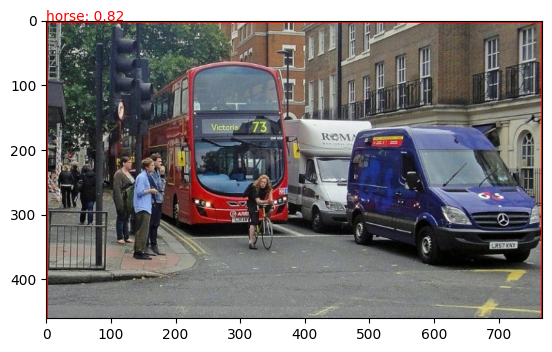

In [126]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def decode_predictions(loc_preds, conf_preds, default_boxes, classes, threshold=0.5):
    """Decodes predictions into bounding boxes, labels, and scores."""

    # Get the class scores and box predictions
    scores = torch.softmax(conf_preds, dim=-1)
    boxes = loc_preds

    # Apply non-maximum suppression to filter overlapping boxes
    pred_boxes, pred_labels, pred_scores = [], [], []

    # ---- FIX: Process only the first prediction (single image)
    # Iterate over only the first image in the batch
    for i in range(1):
        # Filter out background class
        class_scores = scores[i, :, 1:]

        # Get boxes and labels for this image
        boxes_i = boxes[i]
        labels_i = class_scores.argmax(dim=-1) + 1  # Add 1 to account for background class

        # Filter boxes based on threshold
        keep_indices = class_scores.max(dim=-1).values > threshold
        boxes_i = boxes_i[keep_indices]
        labels_i = labels_i[keep_indices]
        scores_i = class_scores[keep_indices].max(dim=-1).values

        # If any boxes remain after filtering
        if boxes_i.size(0) > 0:
            # Decode boxes to get actual coordinates
            decoded_boxes = decode_boxes(boxes_i, default_boxes[keep_indices])  # You'll need to define decode_boxes

            # Apply NMS
            keep_indices_nms = torchvision.ops.nms(decoded_boxes, scores_i, iou_threshold=0.45)

            # Append the filtered predictions
            pred_boxes.extend(decoded_boxes[keep_indices_nms].tolist())
            pred_labels.extend([classes[label] for label in labels_i[keep_indices_nms].tolist()])
            pred_scores.extend(scores_i[keep_indices_nms].tolist())

    return pred_boxes, pred_labels, pred_scores


def decode_boxes(boxes, default_boxes):
    """Decodes predicted box offsets to actual bounding box coordinates."""
    # Assuming boxes are in the format (cx, cy, w, h)
    # and default_boxes are in the format (cx, cy, w, h)

    # Extract box parameters
    cx_pred, cy_pred, w_pred, h_pred = boxes.t()
    cx_default, cy_default, w_default, h_default = default_boxes.t()

    # Decode the box coordinates
    cx = cx_pred * w_default + cx_default
    cy = cy_pred * h_default + cy_default
    w = torch.exp(w_pred) * w_default
    h = torch.exp(h_pred) * h_default

    # Convert to (xmin, ymin, xmax, ymax) format
    xmin = cx - w / 2
    ymin = cy - h / 2
    xmax = cx + w / 2
    ymax = cy + h / 2

    # Clamp the coordinates to be within the image boundaries
    xmin = torch.clamp(xmin, 0, 1)
    ymin = torch.clamp(ymin, 0, 1)
    xmax = torch.clamp(xmax, 0, 1)
    ymax = torch.clamp(ymax, 0, 1)

    # Return the decoded boxes
    return torch.stack([xmin, ymin, xmax, ymax], dim=-1)

def display_results(image_path, model, default_boxes, classes, device, threshold=0.5):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Get predictions for the single image
    with torch.no_grad():
        loc_preds, conf_preds = model(image_tensor)

    # ---- FIX: Pass single image prediction to decode_predictions
    pred_boxes, pred_labels, pred_scores = decode_predictions(
        loc_preds, conf_preds, default_boxes, classes, threshold
    )

    # Display the results
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin * image.width, ymin * image.height), (xmax - xmin) * image.width, (ymax - ymin) * image.height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin * image.width, ymin * image.height, f'{label}: {score:.2f}', color='r')
    plt.show()

# Assuming you have these objects defined
# model, default_boxes, classes, device
# ...
display_results('/content/obj.jpg', model, default_boxes, classes, device)

In [ ]:
# ---- LOAD CLASSES ----
voc_ds = torchvision.datasets.VOCDetection(
    root="./data", year="2007", image_set="trainval", download=True
)
voc_classes = get_voc_classes(voc_ds)
classes = ["background"] + voc_classes
# ---- FIX: Get the correct number of classes from the loaded model
num_classes = checkpoint['conf_heads.0.bias'].shape[0] // 4  # Assuming 4 anchors per feature map


# ---- LOAD MODEL ----
model = SSDModel(num_classes=num_classes)
checkpoint = torch.load("/content/ssd_model.pth", map_location=device)
model.load_state_dict(checkpoint)
model.to(device).eval()

# ---- DEFAULT BOXES ----
default_boxes = generate_default_boxes().to(device)

# ---- DECODING FUNCTIONS ----
def decode_boxes(raw_boxes, dboxes):
    cx_d, cy_d, w_d, h_d = dboxes.t()
    cx_r, cy_r, w_r, h_r = raw_boxes.t()
    cx = cx_r * w_d + cx_d
    cy = cy_r * h_d + cy_d
    w = torch.exp(w_r) * w_d
    h = torch.exp(h_r) * h_d
    xmin = (cx - 0.5 * w).clamp(0, 1)
    ymin = (cy - 0.5 * h).clamp(0, 1)
    xmax = (cx + 0.5 * w).clamp(0, 1)
    ymax = (cy + 0.5 * h).clamp(0, 1)
    return torch.stack([xmin, ymin, xmax, ymax], dim=-1)

def decode_predictions(loc_preds, conf_preds, dboxes, cls_names, score_thr=0.5, iou_thr=0.45):
    with torch.no_grad():
        scores = torch.softmax(conf_preds[0], dim=-1)
        boxes = loc_preds[0]
        cls_scores, cls_inds = scores[:, 1:].max(dim=1)
        keep = cls_scores > score_thr
        if keep.sum() == 0:
            return torch.empty((0,4)), [], []
        boxes_k = boxes[keep]
        scores_k = cls_scores[keep]
        labels_k = cls_inds[keep] + 1
        decoded = decode_boxes(boxes_k, dboxes[keep])
        keep_n = nms(decoded, scores_k, iou_thr)
        decoded = decoded[keep_n].cpu()
        scores_k = scores_k[keep_n].cpu()
        labels_k = labels_k[keep_n].cpu()
        names = [cls_names[i] for i in labels_k.tolist()]
        return decoded, names, scores_k.tolist()

# ---- INFERENCE ----
def run_inference(img_path):
    img = Image.open(img_path).convert("RGB")
    tfm = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    inp = tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        locs, confs = model(inp)
    return img, locs, confs

# ---- VISUALIZATION ----
def display_results(img, locs, confs, dboxes, cls_names, score_thr=0.5):
    W, H = img.size
    boxes, labels, scores = decode_predictions(locs, confs, dboxes, cls_names, score_thr)
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    for box, lab, scr in zip(boxes, labels, scores):
        xmin, ymin, xmax, ymax = box * torch.tensor([W, H, W, H])
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"{lab}: {scr:.2f}", color="white",
                fontsize=12, backgroundcolor="red")
    plt.axis("off")
    plt.show()

# ---- MAIN ----
if __name__ == "__main__":
    img_path = "/content/obj.jpg"
    img, locs, confs = run_inference(img_path)
    display_results(img, locs, confs, default_boxes, classes, score_thr=0.5)




import torch
import torchvision.transforms as transforms
from PIL import Image

# Load the model
model = SSDModel(num_classes)  # Assuming num_classes is defined
model.load_state_dict(torch.load('ssd_model.pth'))
model.eval()  # Set the model to evaluation mode
model.to(device) # Move the model to the device (GPU)